In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# 设置全局字体
# plt.rcParams["font.family"] = "Verdana"
# 设置全局字体为加粗
# plt.rcParams["font.weight"] = "bold"
# plt.rcParams["axes.labelweight"] = "bold"
# 设置全局字体大小
plt.rcParams["font.size"] = 11

device = '4070S'
file = 'decoder_layer.csv'
file_path = f'./{device}/{file}'

# 创建一个横坐标字典
x_dict = {'4096_14336_8': 'Mixtral-8x7B', 
        '2304_5760_8': 'MiniCPM-MoE', 
        '4096_11008_8': 'MiniCPM',
        '6144_16384_8': 'Mixtral-8x22B', 
        '2048_8192_32': 'OpenMoE-8B',
        '3072_12288_32': 'OpenMoE-34B',
        '2048_1408_64': 'DeepSeek',
        '2048_1408_60': 'Qwen2'
        }

# 指定横坐标的顺序
order = ['MiniCPM-MoE', 'OpenMoE-34B', 'Mixtral-8x7B', 'Mixtral-8x22B', 'Qwen2', 'DeepSeek']

# 读取Excel文件
df = pd.read_csv(file_path)

print(df)

        model model type kernel type  iter  batch_size  seq_len  hidden_size  \
0     Mixtral      layer        SSMM   100           1     4096         4096   
1     Mixtral      layer        SSMM   100           1     4096         4096   
2     Mixtral      layer        GEMM   100           1     4096         4096   
3     Mixtral      layer        GEMM   100           1     4096         4096   
4     Mixtral      layer        vLLM   100           1     4096         4096   
5     Mixtral      layer        vLLM   100           1     4096         4096   
6     Mixtral      layer  megablocks   100           1     4096         4096   
7     Mixtral      layer        SSMM   100           1     4096         6144   
8     Mixtral      layer        SSMM   100           1     4096         6144   
9     Mixtral      layer        GEMM   100           1     4096         6144   
10    Mixtral      layer        GEMM   100           1     4096         6144   
11    MiniCPM      layer        SSMM   1

In [3]:
def select_data(df, batch_size_list, para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='eager'):
    # 初始化空字典来存储数据
    data = {}

    # 遍历数据框的每一行
    for index, row in df.iterrows():
        # 获取需要的数据
        batch_size = row['batch_size']
        hidden_size = row['hidden_size']
        intermediate_size = row['intermediate_size']
        kernel_type = row['kernel type']
        time = row['time']
        name = row['model']
        expert_num = row['expert_num']
        
        if batch_size not in batch_size_list:
            continue
        if mode != row['atten_mode']:
            continue
        if (hidden_size, intermediate_size, expert_num) not in para_lists:
            continue

        # 构造name
        name = f"{hidden_size}_{intermediate_size}_{expert_num}"

        # 如果name不在字典中，添加它
        if name not in data:
            data[name] = {'GEMM': 0, 'megablocks': 0, 'vLLM': 0, 'SSMM': 0}

        # 根据kernel type分配时间
        if kernel_type == 'GEMM':
            data[name]['GEMM'] = time
        elif kernel_type == 'vLLM':
            data[name]['vLLM'] = time
        elif kernel_type == 'SSMM':
            data[name]['SSMM'] = time
        elif kernel_type == 'megablocks':
            data[name]['megablocks'] = time

    # 将字典转换为数组
    data_array = [[x_dict[name]] + list(values.values()) for name, values in data.items()]
    
    return data_array

[['Mixtral-8x7B', 5623.924255371094, 5082.05509185791, 5064.470529556274, 3893.413305282593], ['Mixtral-8x22B', 9764.150619506836, 0, 0, 9660.728216171265], ['MiniCPM-MoE', 1959.4762325286863, 1881.1147212982175, 1884.0186595916748, 1522.024154663086], ['OpenMoE-8B', 2845.8263874053955, 0, 0, 1783.3209037780762], ['OpenMoE-34B', 5337.477922439575, 0, 0, 2260.592699050904], ['DeepSeek', 26183.96472930908, 24263.815879821777, 22217.048406600952, 20086.59768104553], ['Qwen2', 22216.104745864868, 21312.752962112427, 20472.64623641968, 19949.041843414307]]


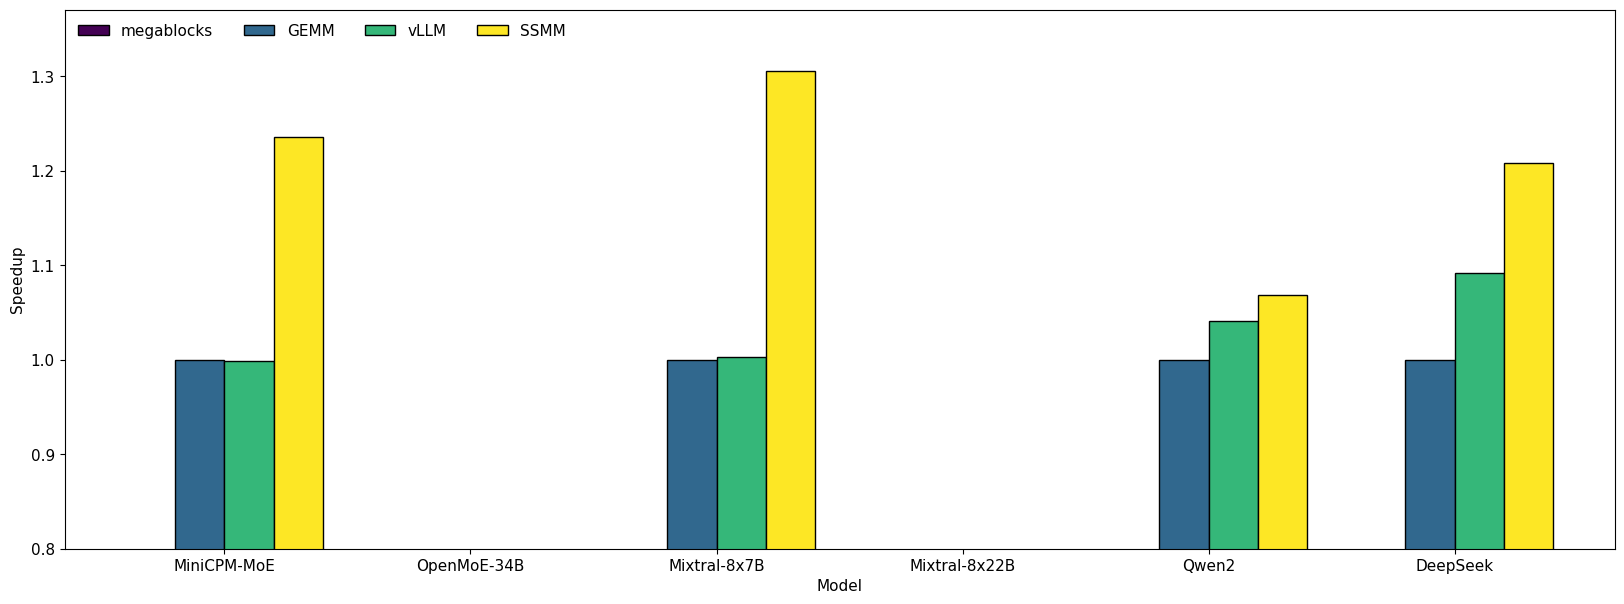

In [4]:
data_array = select_data(df, batch_size_list=[1,16,14], para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='flash_attention_2')
# data_array = select_data(df, batch_size_list=[1], para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='eager')
print(data_array)
# 将data_array转换为pandas数据框
data_df = pd.DataFrame(data_array, columns=['name', 'megablocks', 'GEMM', 'vLLM', 'SSMM'])
    
# 归一化到'GEMM_time'
data_df['vLLM'] = data_df['GEMM'] / data_df['vLLM'] 
data_df['SSMM'] = data_df['GEMM'] / data_df['SSMM']
data_df['GEMM'] = data_df['GEMM'] / data_df['GEMM']
data_df['megablocks'] = data_df['GEMM'] / data_df['megablocks']

# 设置name列为索引
data_df.set_index('name', inplace=True)

# 对数据框进行排序
data_df = data_df.loc[order]

# 绘制柱状图
ax = data_df.plot.bar(rot=0, figsize=(20,7), width=0.8, colormap='viridis', edgecolor='black')

# 设置y轴的范围
ax.set_ylim([0.8, ax.get_ylim()[1]])

# 将图例放在右上角，三个示例放在一行，图例无边框，里面无颜色填充
legend = ax.legend(loc='upper left', ncol=4, frameon=True)
legend.get_frame().set_edgecolor('none')
legend.get_frame().set_facecolor('none')

# Set labels and title with enhanced formatting
ax.set_xlabel("Model")
ax.set_ylabel("Speedup")

# 显示图形
plt.show()

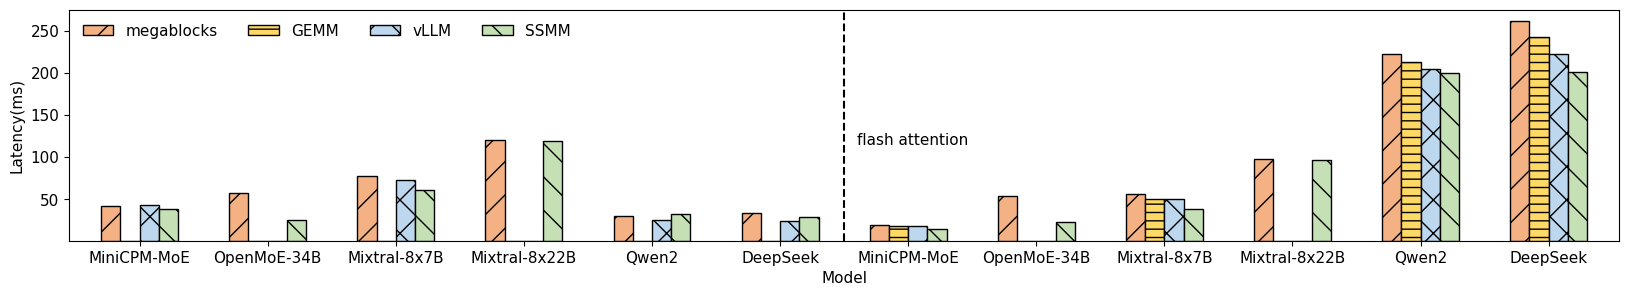

In [5]:
flash_attention_data_array = select_data(df, batch_size_list=[1,16,14], para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='flash_attention_2')
# 将data_array转换为pandas数据框
flash_attention_data_df = pd.DataFrame(flash_attention_data_array, columns=['name', 'megablocks', 'GEMM', 'vLLM', 'SSMM'])
# 设置name列为索引
flash_attention_data_df.set_index('name', inplace=True)
# 对数据框进行排序
flash_attention_data_df = flash_attention_data_df.loc[order]

eager_data_array = select_data(df, batch_size_list=[1], para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='eager')
# 将data_array转换为pandas数据框
eager_data_df = pd.DataFrame(eager_data_array, columns=['name', 'megablocks', 'GEMM', 'vLLM', 'SSMM'])
# 设置name列为索引
eager_data_df.set_index('name', inplace=True)
# 对数据框进行排序
eager_data_df = eager_data_df.loc[order]

data_df = pd.concat([eager_data_df, flash_attention_data_df], ignore_index=False)

# 统一每次的latency(ms)
data_df['vLLM'] = data_df['vLLM'] / 100
data_df['SSMM'] = data_df['SSMM'] / 100
data_df['megablocks'] = data_df['megablocks'] / 100
data_df['GEMM'] = data_df['GEMM'] / 100

# # 对数据框进行排序
# data_df = data_df.loc[order]

# 绘制柱状图
# colors = ['#F4B183', '#FFD966', '#C5E0B4', '#BDD7EE']
colors = ['#F4B183', '#FFD966', '#BDD7EE', '#C5E0B4']
ax = data_df.plot.bar(rot=0, figsize=(20,3), width=0.6, color=colors, edgecolor='black')

# 给每个颜色的柱子加上不同的填充hatch
hatches = ['/', '--', 'x', '\\']  # 定义填充样式
color_to_hatch = dict(zip(colors, hatches))
for i, bar in enumerate(ax.patches):
    hex_color = mcolors.to_hex(bar.get_facecolor()).upper()
    bar.set_hatch(color_to_hatch[hex_color])

# 中间灰色的分割线
ax.axvline(x=len(flash_attention_data_array)-1.5, linestyle='--', color='black')
# 右边的字
ax.text(len(flash_attention_data_array)-1.4, 115, 'flash attention', ha='left')

# 设置y轴的范围
ax.set_ylim([0.8, ax.get_ylim()[1]])

# 将图例放在右上角，三个示例放在一行，图例无边框，里面无颜色填充
legend = ax.legend(loc='upper left', ncol=4, frameon=True)
legend.get_frame().set_edgecolor('none')
legend.get_frame().set_facecolor('none')

# Set labels and title with enhanced formatting
ax.set_xlabel("Model")
ax.set_ylabel("Latency(ms)")

# 显示图形
plt.show()

               GEMM  megablocks      vLLM      SSMM
name                                               
MiniCPM-MoE     1.0    1.041657  1.040051  1.287415
OpenMoE-34B     1.0         inf       inf  2.361097
Mixtral-8x7B    1.0    1.106624  1.110466  1.444471
Mixtral-8x22B   1.0         inf       inf  1.010705
Qwen2           1.0    1.042386  1.085160  1.113643
DeepSeek        1.0    1.079136  1.178553  1.303554


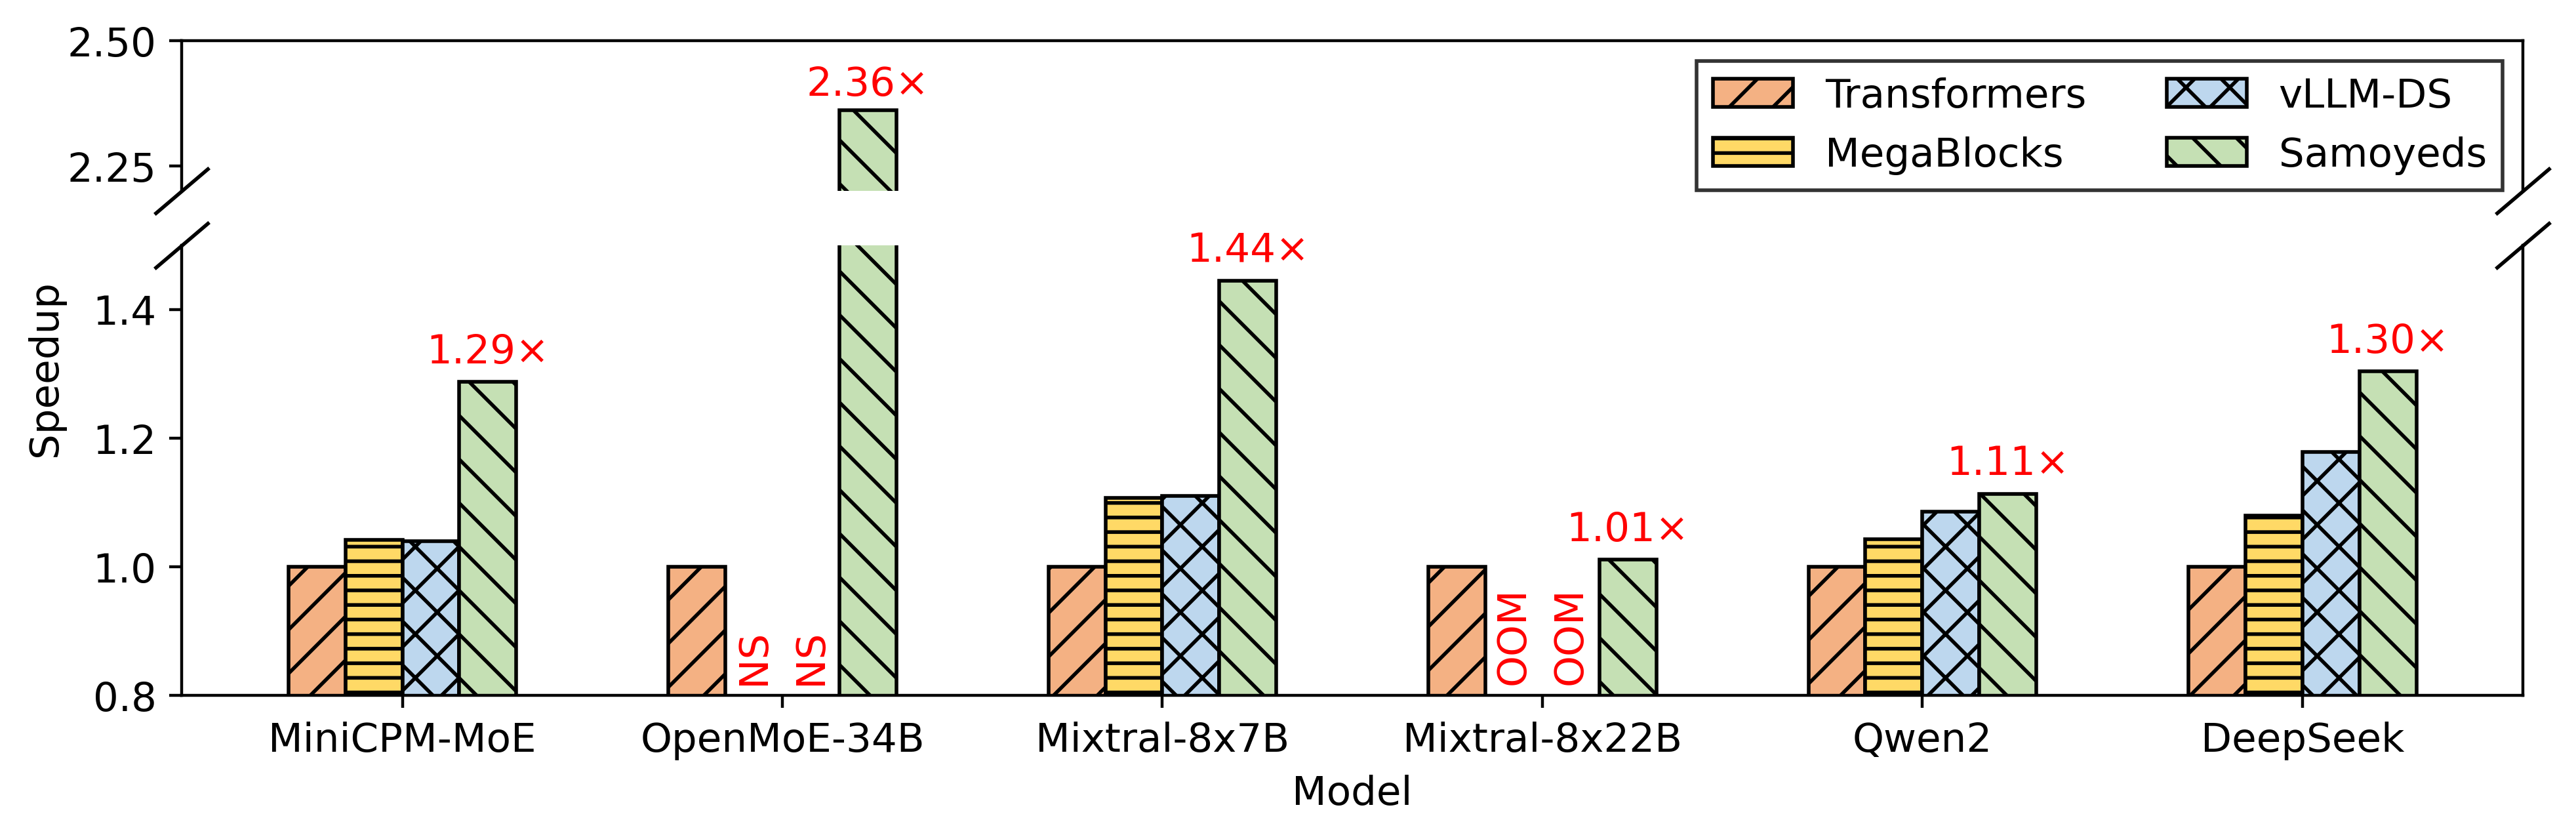

In [8]:
flash_attention_data_array = select_data(df, batch_size_list=[1,16,14], para_lists=[(4096,14336,8), (2304,5760,8), (6144,16384,8), (2048,8192,32), (3072,12288,32), (2048,1408,64), (2048,1408,60)], mode='flash_attention_2')

# 将data_array转换为pandas数据框
flash_attention_data_df = pd.DataFrame(flash_attention_data_array, columns=['name', 'GEMM', 'megablocks', 'vLLM', 'SSMM'])
# 设置name列为索引
flash_attention_data_df.set_index('name', inplace=True)
# 对数据框进行排序
data_df = flash_attention_data_df.loc[order]

# 统一speedup
data_df['megablocks'] = data_df['GEMM'] / data_df['megablocks']
data_df['vLLM'] = data_df['GEMM'] / data_df['vLLM']
data_df['SSMM'] = data_df['GEMM'] / data_df['SSMM']
data_df['GEMM'] = data_df['GEMM'] / data_df['GEMM']

print(data_df)

# 列名替换
data_df.rename(columns={'GEMM': 'Transformers', 'megablocks': 'MegaBlocks', 'vLLM': 'vLLM-DS', 'SSMM': 'Samoyeds'}, inplace=True)

import matplotlib.gridspec as gridspec

# 创建一个GridSpec对象
gs = gridspec.GridSpec(2, 1, height_ratios=[1,3])

fig = plt.figure(figsize=(10, 3), dpi=400)

# 使用GridSpec对象来创建子图
ax2 = plt.subplot(gs[1])
ax1 = plt.subplot(gs[0])

# fig, (ax1, ax2) = plt.subplots(2, 1, sharex=True, figsize=(10,3), dpi=400)

ax1.set_ylim(2.2, 2.5)  # 子图1设置y轴范围，只显示部分图
ax2.set_ylim(0.8, 1.5)  # 子图2设置y轴范围，只显示部分图

ax1.tick_params(axis='x', which='both', bottom=False)

import numpy as np
x = np.arange(len(data_df.index))
width = 0.15
# colors = ['#F4B183', '#FFD966', '#C5E0B4', '#BDD7EE']
colors = ['#F4B183', '#FFD966', '#BDD7EE', '#C5E0B4']
# 给每个颜色的柱子加上不同的填充hatch
hatches = ['//', '---', 'xx', '\\\\'] # 定义填充样式

# 对于每一列数据，绘制一个柱子
for i, (column, color, hatch) in enumerate(zip(data_df.columns, colors, hatches)):
    ax1.bar(x - width/2 - width + i*width, data_df[column].values, width=width, color=color, edgecolor='black', hatch=hatch, label=column)
    ax2.bar(x - width/2 - width + i*width, data_df[column].values, width=width, color=color, edgecolor='black', hatch=hatch, label=column)

for i, bar in enumerate(ax1.patches):
    if i == 19:
        ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{bar.get_height():.2f}\u00D7', ha='center', color='red')

for i, bar in enumerate(ax2.patches):
    if i/data_df.shape[0] >= 3:
        if i != 19:
            ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.03, f'{bar.get_height():.2f}\u00D7', ha='center', color='red')

ax1.spines['bottom'].set_visible(False)#关闭子图1中底部脊
ax2.spines['top'].set_visible(False)##关闭子图2中顶部脊
ax2.set_xticks(x)
ax2.set_xticklabels(data_df.index, rotation=0)
ax1.set_xticklabels([])

# legend = ax1.legend(loc='upper center', bbox_to_anchor=(0.5, 1.47), ncol=4, frameon=False)
# legend = ax1.legend(loc='upper right', ncol=2, frameon=False)
legend = ax1.legend(loc='upper right', ncol=2, frameon=True, fancybox=False)
legend.get_frame().set_edgecolor('black')
legend.get_frame().set_facecolor('none')

# OpenMoE no supported
ax2.text((ax2.patches[7].get_x() + ax2.patches[13].get_x())/2, 0.83, 'NS', ha='center', rotation=90, color='red')
ax2.text((ax2.patches[13].get_x() + ax2.patches[19].get_x())/2, 0.83, 'NS', ha='center', rotation=90, color='red')
# OOM
ax2.text((ax2.patches[9].get_x() + ax2.patches[15].get_x())/2, 0.83, 'OOM', ha='center', rotation=90, color='red')
ax2.text((ax2.patches[15].get_x() + ax2.patches[21].get_x())/2, 0.83, 'OOM', ha='center', rotation=90, color='red')

d = .85  #设置倾斜度
#绘制断裂处的标记
kwargs = dict(marker=[(-1, -d), (1, d)], markersize=15,
              linestyle='none', color='black', mec='black', mew=1, clip_on=False)
ax1.plot([0, 1], [0, 0],transform=ax1.transAxes, **kwargs)
ax2.plot([0, 1], [1, 1], transform=ax2.transAxes, **kwargs)

# Set labels and title with enhanced formatting
ax2.set_xlabel("Model")
# 创建一个新的Axes对象，用于设置整张图的y轴标签
ax = fig.add_subplot(111, frame_on=False)
ax.set_ylabel("Speedup")
ax.yaxis.set_label_coords(-0.05, 0.5)

# 隐藏新Axes对象的x轴和y轴
ax.xaxis.set_ticks([])
ax.yaxis.set_ticks([])

plt.tight_layout(pad=0)

plt.savefig('4070S/figures/layer_speedup.pdf', bbox_inches='tight', dpi=400)

plt.show()
